In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from dataloaders import TaskILMNIST, DomainILMNIST, ClassILMNIST

# Visualize Domains

In [19]:
def visualize_domains(data_class, num_tasks, batch_size, loader = None):
    
    if loader == None:
        task_loader = data_class(num_tasks=num_tasks, batch_size=batch_size)
        tasks_dataloaders = task_loader.get_all_dataloaders()
    else:
        tasks_dataloaders = loader

    for task_id, (train_loader, test_loader) in enumerate(tasks_dataloaders):
        plt.figure(figsize=(15, 2))
        batch_img, batch_targets = next(iter(train_loader))
        batch_img = batch_img.reshape(-1, 28, 28)
        for img_index in range(5):
            plt.subplot(1, 5, img_index+1)
            plt.imshow(batch_img[img_index].numpy())
            plt.title(f"Task {task_id} - Label {batch_targets[img_index].argmax()}")

## Task Incremental Learning

Splits MNIST into 5 tasks with 2 classes each (0-1, 2-3, 4-5, 6-7, 8-9). Each task has distinct classes. Model needs to predict both class and task. 
Note: With task-incremental learning, at the  computational level, there is no difference between whether the algorithm must return the within-context label or the global label, because the within-context label can be combined with the context label (which is provided as input) to get the global label.

Basically, we always want a [0,1] (even, odd) outcome for the classes. The network must map the new classes to even odd despite the task shift. 

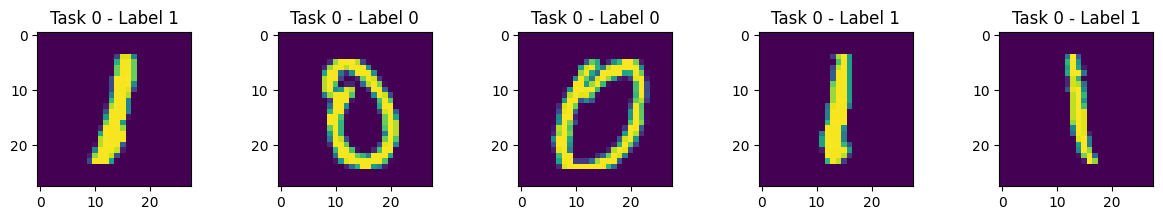

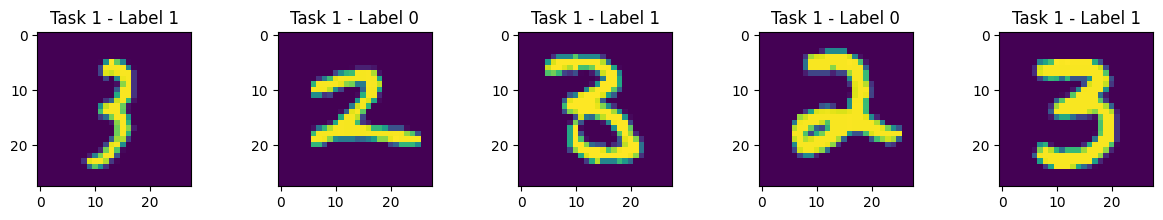

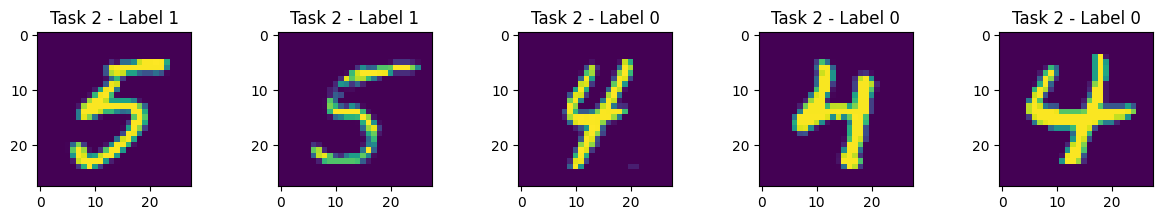

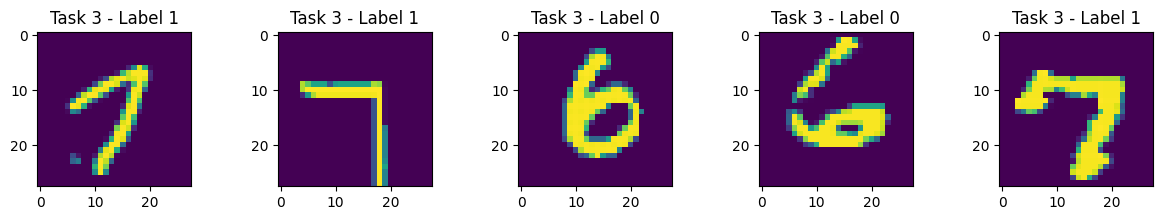

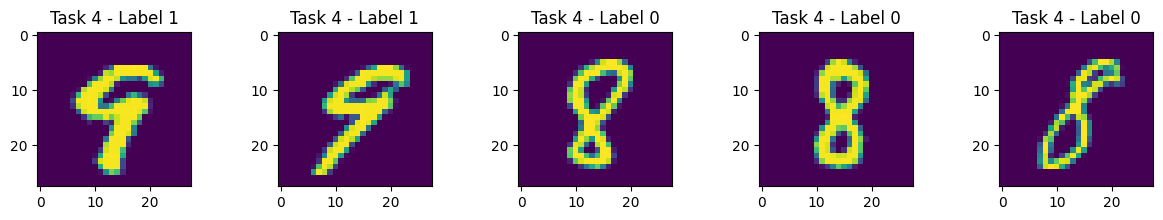

In [14]:
visualize_domains(TaskILMNIST, num_tasks=5, batch_size=64)

## Domain Incremental Learning

Uses all 10 classes in each task. Different "domains" simulated by applying different rotation angles. Model needs to handle same classes with different distributions

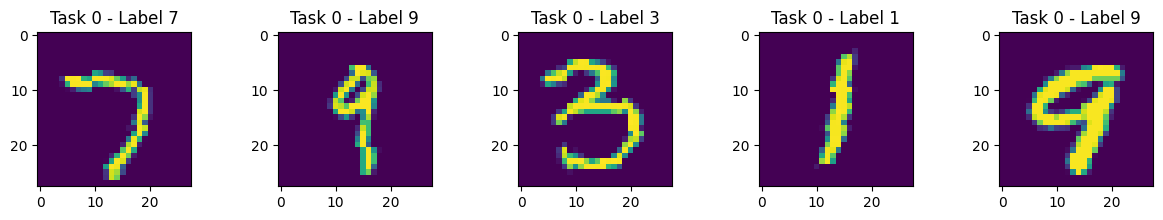

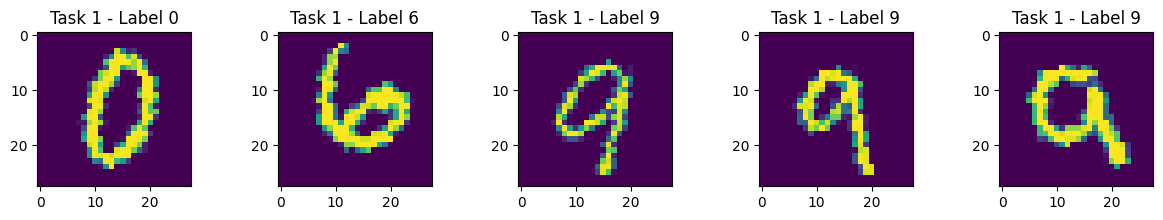

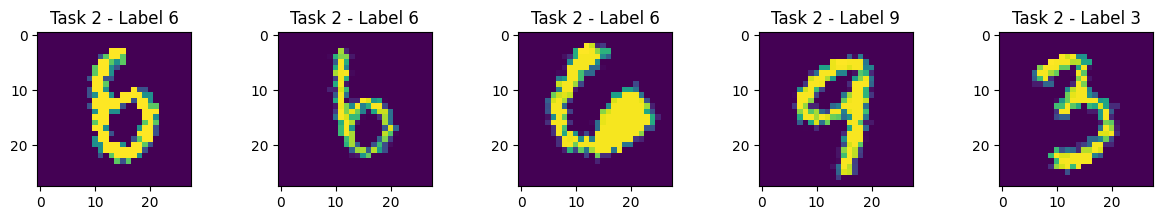

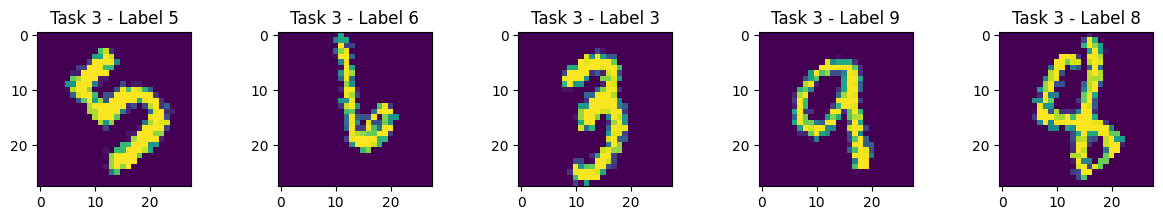

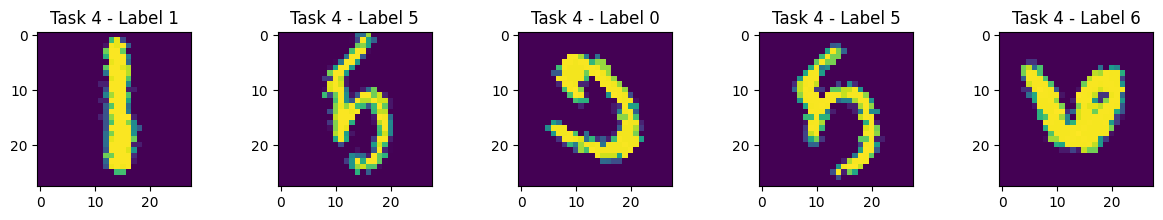

In [12]:
visualize_domains(DomainILMNIST, num_tasks=5, batch_size=64)

## Class Incremental Learning

Similar to Task-IL split (2 classes per task). Model learns classes sequentially without task information at test time. 

It remains to be discussed whether the labels must be 0/1 or the "global" ones.

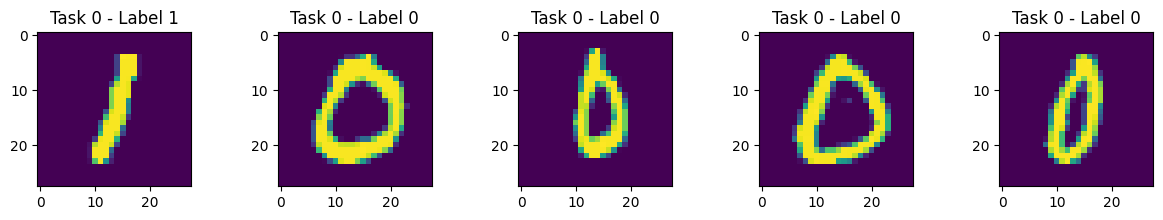

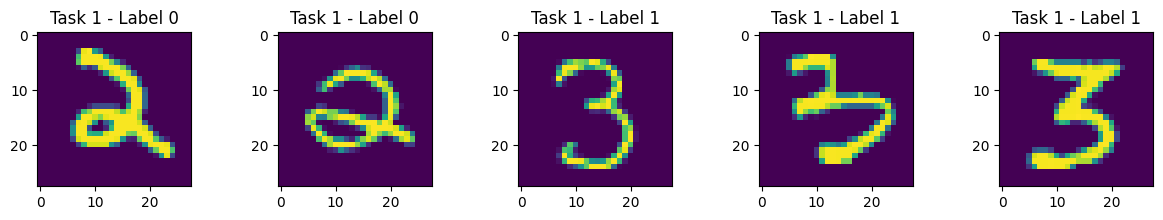

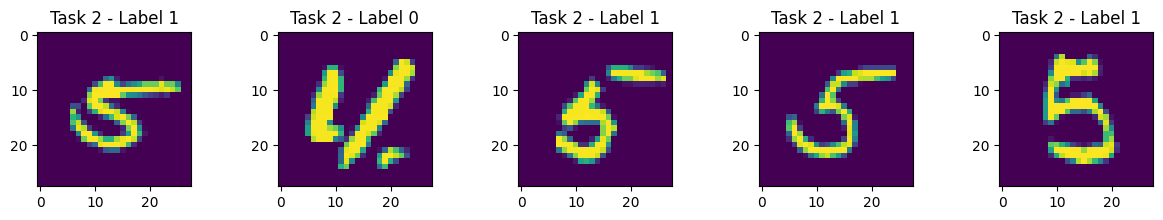

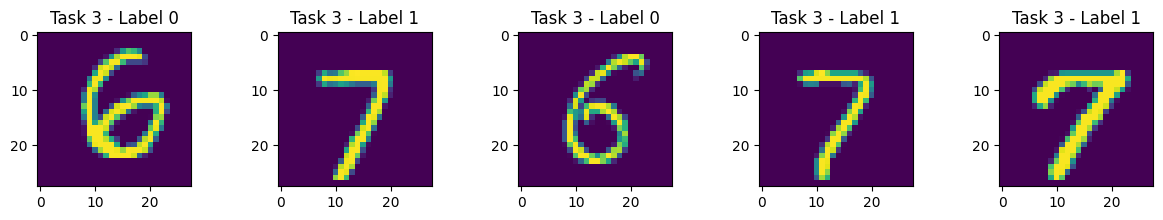

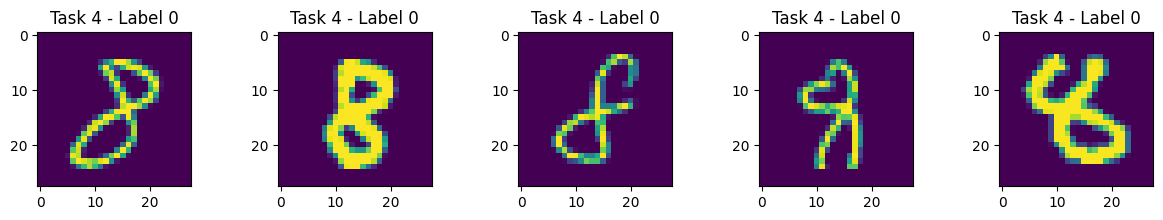

In [ ]:
visualize_domains(ClassILMNIST, num_tasks=5, batch_size=64)

cl = ClassILMNIST(num_tasks=5, batch_size=64)
dl = cl.get_all_dataloaders()
for i, (train_loader, test_loader) in enumerate(dl):
    print(f"Task {i}")
    

# original Split MNIST from Sander

In [16]:
from src.datasets import SplitMNIST
from src.utils import dotdict
config = {
        "layers": [784, 400, 400, 2],
        "lr": 1.5e-6,
        "batch_size": 128,
        "epochs": 20,
        "mode": "di",  # or "di"
        "num_workers": 8,
        "loss_fn": "ce", # "mse"
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "device": "cpu",
        "output_dir": "./outputs",
        "seed": 1337,
        "target_lr": 1e-2, # needs to be < time_constant_ratio
        "alpha_di": 1e-4,
        "taus": [0.01, 0.008, 0.006],
        "dt_di": 0.008,  # dynamical inversion params
        "time_constant_ratio": 0.2, # this param can be merged with dt_di
        "tmax_di": 500,
        "k_p": 2.0,
        "eps": 1e-4, # there is an interplay between dt_di and eps
        "save": False,
        "importance_ewc": 1.0, # ewc params
        "beta_efc": 5.0, # efc params
    }
config = dotdict(config)
split_MNIST = SplitMNIST(config=config).get_all_tasks_dataloaders()


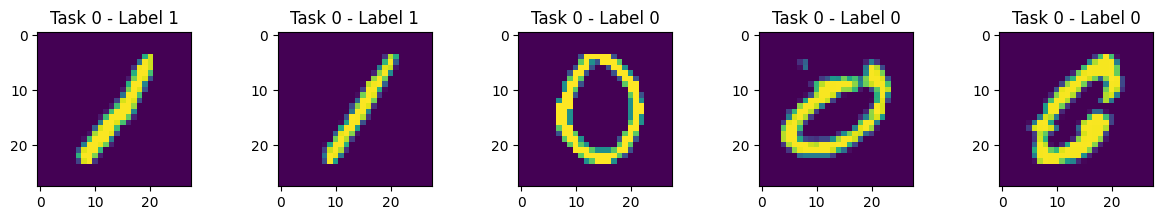

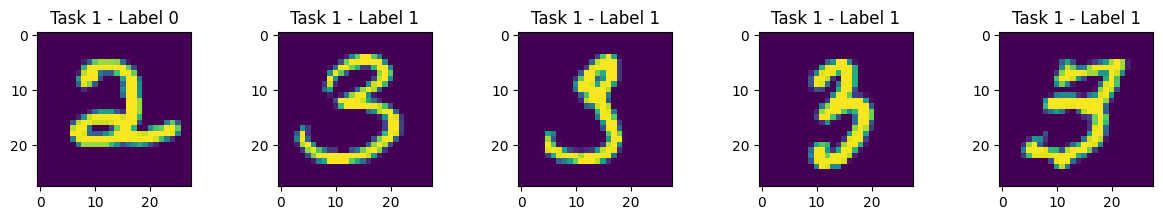

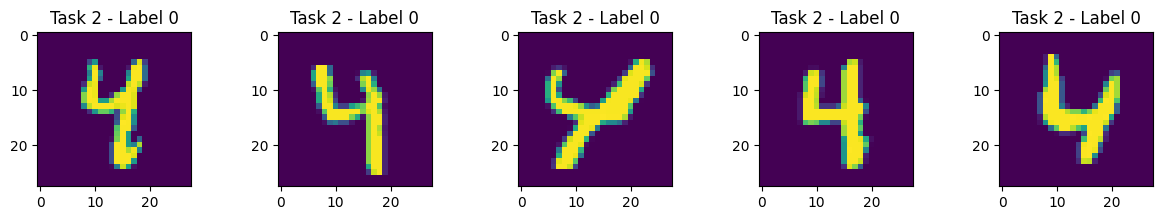

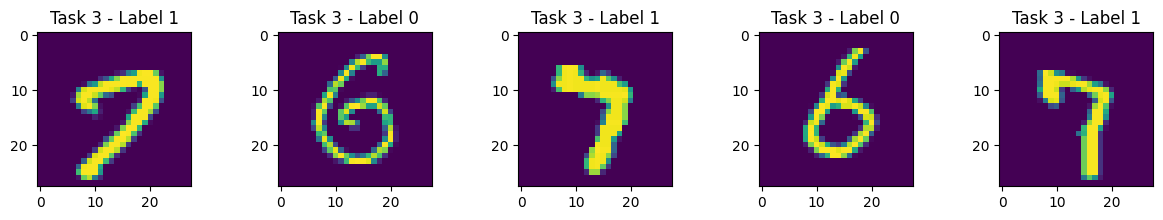

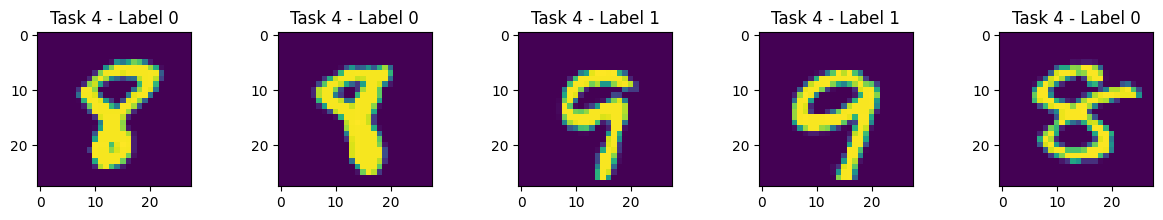

In [20]:
visualize_domains(_, _, _, loader=split_MNIST)